# Continuous and Time-Series Causal Discovery

**Chapter 15: Causal Machine Learning**
**Docker image**: `ml4t`

**Book Reference**: Chapter 15, §15.6 (Causal Discovery from Observational Data)

This notebook compares continuous DAG learning with time-series discovery methods on
one seven-ETF panel, emphasizing how strongly the resulting graph depends on assumptions.

**Why Compare Discovery Methods?**

Constraint-based methods such as PC, FCI, and PCMCI test conditional independence
to recover graph structure or an equivalence class, depending on their assumptions.
They have limitations:
1. **Combinatorial explosion**: Testing all possible edges is expensive
2. **Discrete decisions**: No gradient-based optimization
3. **Limited scalability**: Struggles with many variables

The comparison includes:
- **NOTEARS** for contemporaneous linear DAG learning
- **VAR-LiNGAM** for lagged and instantaneous linear structure
- **PCMCI** for multivariate conditional-independence discovery
- **Granger tests** as pairwise predictive screens

**Learning Outcomes**:
- LO1: Understand the NOTEARS formulation for DAG learning
- LO2: Apply contemporaneous and lagged discovery methods to financial time series
- LO3: Compare score-based and constraint-based methods with proper multiple testing
- LO4: Assess edge stability via bootstrap analysis

**Prerequisites**: [`07_tigramite_time_series`](07_tigramite_time_series.ipynb) for constraint-based
discovery; ETF OHLCV data from Ch2 data pipeline

## 1. Setup and Configuration

In [1]:
"""Compare continuous DAG learning with time-series causal discovery."""

import io
from collections import defaultdict
from contextlib import redirect_stdout
from datetime import datetime

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from causallearn.search.FCMBased.lingam import VARLiNGAM
from IPython.display import display
from scipy import linalg, optimize
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import grangercausalitytests
from tigramite import data_processing as pp
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.pcmci import PCMCI

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

In [2]:
N_SAMPLES = 2000
MAX_LAG = 3
N_BOOTSTRAP = 100
SEED = 42
BLOCK_SIZE = 20
SYNTHETIC_SAMPLE_SIZE = 0
RETURN_SAMPLE_LIMIT = 0
NOTEARS_LAMBDA1 = 0.05
NOTEARS_MAX_ITER = 100
BOOTSTRAP_MAX_ITER = 30
GRANGER_MAX_LAG = 5
START_DATE = "2015-01-01"
END_DATE = "2024-06-01"

In [3]:

set_global_seeds(SEED)

print("Continuous and Time-Series Causal Discovery")
print(f"Bootstrap iterations: {N_BOOTSTRAP}")

Continuous and Time-Series Causal Discovery
Bootstrap iterations: 100


## 2. The NOTEARS Algorithm

The implementation below is the notebook's own. Every other method here is imported:
VAR-LiNGAM from `causal-learn`, PCMCI and its partial-correlation test from `tigramite`,
the Granger tests from `statsmodels`. `causal-learn` is the library a reader would expect
NOTEARS to live in, and it ships no NOTEARS, so a continuous-optimization baseline has to
be written out. That suits the teaching: the augmented-Lagrangian loop is short enough to
read, and the acyclicity constraint is the whole idea.

**NOTEARS** (Zheng et al., 2018) reformulates DAG learning as:

$$\min_W \frac{1}{2n} \|X - XW\|_F^2 + \lambda \|W\|_1$$
$$\text{subject to } h(W) = \text{tr}(e^{W \circ W}) - d = 0$$

Where:
- $W$ is the weighted adjacency matrix (W[i,j] = edge i→j)
- $h(W) = 0$ is the **acyclicity constraint** (trace exponential trick)
- The $\ell_1$ penalty induces sparsity

The key insight: $h(W) = 0$ iff $W$ represents a DAG. This makes the
combinatorial problem continuous and differentiable.

In [4]:
def _notears_objectives(X, n, d):
    """Build the NOTEARS least-squares loss and acyclicity constraint.

    Each returns ``(value, gradient)`` so the augmented-Lagrangian subproblem
    can be handed to a smooth optimizer (Zheng et al., 2018).
    """

    def loss(W):
        R = X - X @ W
        value = 0.5 / n * np.sum(R**2)
        grad = -1.0 / n * X.T @ R
        return value, grad

    def h(W):
        # h(W) = tr(exp(W∘W)) - d, which is zero iff W encodes a DAG.
        E = linalg.expm(W * W)
        value = np.trace(E) - d
        grad = E.T * W * 2
        return value, grad

    return loss, h

Each augmented-Lagrangian step solves one smooth, bounded optimization problem over
positive and negative parts of the adjacency matrix.

In [5]:
def _solve_notears_subproblem(w_est, d, loss, h, rho, alpha, lambda1):
    """Solve one NOTEARS augmented-Lagrangian subproblem."""

    def adjacency(w):
        return (w[: d * d] - w[d * d :]).reshape(d, d)

    def objective(w):
        W = adjacency(w)
        loss_val, g_loss = loss(W)
        h_cur, g_h = h(W)
        value = loss_val + 0.5 * rho * h_cur**2 + alpha * h_cur + lambda1 * w.sum()
        g_smooth = g_loss + (rho * h_cur + alpha) * g_h
        gradient = np.concatenate((g_smooth + lambda1, -g_smooth + lambda1), axis=None)
        return value, gradient

    bounds = [(0, 0) if i == j else (0, None) for _ in range(2) for i in range(d) for j in range(d)]
    solution = optimize.minimize(objective, w_est, method="L-BFGS-B", jac=True, bounds=bounds)
    W_new = adjacency(solution.x)
    return solution.x, W_new, h(W_new)[0]

The outer loop raises the acyclicity penalty until the graph satisfies the smooth DAG
constraint, then thresholds small coefficients for a readable sparse graph.

In [6]:
def notears_linear(
    X: np.ndarray,
    lambda1: float = 0.1,
    max_iter: int = 100,
    h_tol: float = 1e-8,
    rho_max: float = 1e16,
    w_threshold: float = 0.3,
) -> np.ndarray:
    """NOTEARS linear DAG learning via the augmented Lagrangian (Zheng et al., 2018).

    The L1-penalized least-squares objective is minimized under the smooth
    acyclicity constraint ``h(W) = 0``. Each subproblem is solved with L-BFGS-B
    over the ``(W+, W-)`` positive-part split that makes the L1 term
    differentiable, then ``rho`` is escalated until the constraint is met.
    """
    n, d = X.shape
    loss, h = _notears_objectives(X, n, d)
    rho, alpha, h_val = 1.0, 0.0, np.inf
    w_est = np.zeros(2 * d * d)
    W_est = np.zeros((d, d))

    for _ in range(max_iter):
        while rho < rho_max:
            w_new, W_new, h_new = _solve_notears_subproblem(w_est, d, loss, h, rho, alpha, lambda1)
            if h_new > 0.25 * h_val:
                rho *= 10
            else:
                break
        w_est, W_est, h_val = w_new, W_new, h_new
        alpha += rho * h_val
        if h_val <= h_tol or rho >= rho_max:
            break

    W_est[np.abs(W_est) < w_threshold] = 0
    return W_est

## 3. VAR-LiNGAM: Combining VAR with Non-Gaussianity

**VAR-LiNGAM** extends the Linear Non-Gaussian Acyclic Model to time series:
1. Fit a VAR model to capture lagged relationships
2. Apply ICA to residuals to identify instantaneous causal order
3. Use non-Gaussianity for identification (unlike Gaussian methods)

We first fit an explicit ridge-VAR screen to expose the lagged regression step,
then use the full `causal-learn` VAR-LiNGAM implementation for structural discovery.

### Explicit VAR Screen

A one-lag ridge VAR provides an intentionally modest reference. It estimates predictive
lagged coefficients but does not claim to solve LiNGAM's ICA permutation and scaling problem.

In [7]:
def ridge_var_screen(
    X: np.ndarray,
    threshold: float = 0.1,
) -> np.ndarray:
    """Estimate a one-lag ridge VAR coefficient matrix for comparison."""
    _, d = X.shape
    Y = X[1:]
    X_lagged = X[:-1]

    B_lag = np.zeros((d, d))
    for j in range(d):
        model = Ridge(alpha=1.0)
        model.fit(X_lagged, Y[:, j])
        B_lag[j, :] = model.coef_

    B_lag[np.abs(B_lag) < threshold] = 0
    return B_lag

### Library Implementation: causal-learn

The `causal-learn` library provides a production-grade `VARLiNGAM` that fits the
requested one-lag VAR, applies DirectLiNGAM to the innovations for instantaneous
ordering, and optionally prunes the result - all in three lines.

In [8]:
def var_lingam_library(
    X: np.ndarray,
    lags: int = 1,
    threshold: float = 0.1,
) -> tuple[np.ndarray, np.ndarray]:
    """VAR-LiNGAM via causal-learn: proper VAR + DirectLiNGAM on residuals."""
    model = VARLiNGAM(lags=lags, criterion=None, prune=True, random_state=SEED)
    model.fit(X)

    B0 = model.adjacency_matrices_[0].copy()
    B_lag = model.adjacency_matrices_[1].copy()

    B0[np.abs(B0) < threshold] = 0
    B_lag[np.abs(B_lag) < threshold] = 0
    return B0, B_lag

## 4. Block Bootstrap for Stability Analysis

Continuous DAG estimates are sensitive to noise. We assess edge stability via block
bootstrap (preserving autocorrelation) to see how often each edge appears.

In [9]:
def block_bootstrap_indices(n: int, block_size: int = 20) -> np.ndarray:
    """
    Generate block bootstrap indices preserving temporal dependence.

    Args:
        n: Length of time series
        block_size: Size of contiguous blocks

    Returns:
        Bootstrapped indices
    """
    n_blocks = n // block_size + 1
    # Sample blocks with replacement
    block_starts = np.random.randint(0, n - block_size + 1, size=n_blocks)
    # Concatenate blocks
    indices = np.concatenate([np.arange(start, start + block_size) for start in block_starts])
    return indices[:n]  # Trim to original length

Convert weighted adjacency matrices into edge sets for evaluation and stability counting.

In [10]:
def extract_edges(W: np.ndarray, labels: list, threshold: float = 0.0) -> set:
    """Extract edges from adjacency matrix as set of tuples."""
    edges = set()
    for i in range(len(labels)):
        for j in range(len(labels)):
            if abs(W[i, j]) > threshold:
                edges.add((labels[i], labels[j]))
    return edges

## 5. Synthetic Validation with Known Ground Truth

Before applying to real data, we validate methods on synthetic data
with known causal structure to measure precision and sensitivity.

The generator is the linear SEM that NOTEARS targets (Zheng et al. 2018): equal-variance
noise on a unit scale, with accumulating coefficients along the known DAG
X0 -> X1 -> X2, X0 -> X2, X2 -> X3 -> X4. Downstream variables inherit their parents'
variance, so the variance ordering lines up with the causal order and the orientation is
identifiable from observational data alone.

In [11]:
print("\n=== SYNTHETIC VALIDATION ===\n")

n_synthetic = SYNTHETIC_SAMPLE_SIZE if SYNTHETIC_SAMPLE_SIZE > 0 else N_SAMPLES
TRUE_EDGES = {(0, 1), (1, 2), (0, 2), (2, 3), (3, 4)}

np.random.seed(SEED)
X_syn = np.zeros((n_synthetic, 5))
X_syn[:, 0] = np.random.randn(n_synthetic)
X_syn[:, 1] = 0.8 * X_syn[:, 0] + np.random.randn(n_synthetic)
X_syn[:, 2] = 0.7 * X_syn[:, 0] + 0.8 * X_syn[:, 1] + np.random.randn(n_synthetic)
X_syn[:, 3] = 0.9 * X_syn[:, 2] + np.random.randn(n_synthetic)
X_syn[:, 4] = 0.8 * X_syn[:, 3] + np.random.randn(n_synthetic)


=== SYNTHETIC VALIDATION ===



In [12]:
# Run NOTEARS and compute precision/sensitivity against known truth
W_syn = notears_linear(X_syn, lambda1=0.05, max_iter=50)
discovered_edges = extract_edges(W_syn, list(range(5)))

tp = len(discovered_edges & TRUE_EDGES)
fp = len(discovered_edges - TRUE_EDGES)
fn = len(TRUE_EDGES - discovered_edges)
precision = tp / max(len(discovered_edges), 1)
sensitivity = tp / len(TRUE_EDGES)
f1_score = 2 * precision * sensitivity / max(precision + sensitivity, 1e-6)

print(f"  Discovered: {discovered_edges}")
print(f"  TP={tp}, FP={fp}, FN={fn}")
print(f"  Precision: {precision:.1%}, Sensitivity: {sensitivity:.1%}, F1: {f1_score:.2f}")

SYNTHETIC_RESULTS = {"precision": precision, "sensitivity": sensitivity, "f1": f1_score}

  Discovered: {(0, 1), (1, 2), (3, 4), (2, 3), (0, 2)}
  TP=5, FP=0, FN=0
  Precision: 100.0%, Sensitivity: 100.0%, F1: 1.00


## 6. Load Financial Time Series Data

We use multi-asset ETF returns to discover causal structure.

In [13]:
print("\n=== LOADING DATA ===\n")

# Configuration
ASSETS = ["SPY", "QQQ", "IWM", "TLT", "GLD", "EEM", "XLF"]

# Load ETF data
etf_data = load_etfs()

# Filter to assets and date range
start_dt = datetime.fromisoformat(START_DATE)
end_dt = datetime.fromisoformat(END_DATE)

etf_data = etf_data.filter(
    (pl.col("symbol").is_in(ASSETS))
    & (pl.col("timestamp") >= start_dt)
    & (pl.col("timestamp") <= end_dt)
)


=== LOADING DATA ===



In [14]:
# Pivot to wide format
prices = (
    etf_data.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
)

# Keep ordinary table transformations in Polars. NumPy and pandas conversions occur
# only at estimator and display boundaries below.
ASSETS = [asset for asset in ASSETS if asset in prices.columns]
returns = prices.select(
    "timestamp",
    *[(pl.col(asset) / pl.col(asset).shift(1) - 1).alias(asset) for asset in ASSETS],
).drop_nulls()

if RETURN_SAMPLE_LIMIT > 0:
    returns = returns.tail(RETURN_SAMPLE_LIMIT)

print(f"Assets: {ASSETS}")
sample_start = datetime.fromisoformat(str(returns["timestamp"].min()))
sample_end = datetime.fromisoformat(str(returns["timestamp"].max()))
print(f"Sample period: {sample_start} to {sample_end}")
print(f"Observations: {len(returns)}")

# Keep raw returns so every bootstrap replicate can refit its own scaler. The full-sample
# transform below is used only for the descriptive full-period estimates.
X_raw = returns.select(ASSETS).to_numpy()
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"\nData shape: {X.shape}")

Assets: ['SPY', 'QQQ', 'IWM', 'TLT', 'GLD', 'EEM', 'XLF']
Sample period: 2015-01-05 00:00:00 to 2024-05-31 00:00:00
Observations: 2368

Data shape: (2368, 7)


## 7. Apply NOTEARS with Bootstrap Stability

In [15]:
print("\n=== NOTEARS CAUSAL DISCOVERY WITH STABILITY ===\n")

# Apply NOTEARS to full data
lambda1 = NOTEARS_LAMBDA1
W_notears = notears_linear(X, lambda1=lambda1, max_iter=NOTEARS_MAX_ITER)

# Create adjacency dataframe
adj_df = pd.DataFrame(W_notears, index=ASSETS, columns=ASSETS)

print("Discovered Adjacency Matrix (NOTEARS):")
display(adj_df.round(3))

# Count full-sample edges
full_sample_edges = extract_edges(W_notears, ASSETS)
n_edges = len(full_sample_edges)
print(f"\nTotal edges discovered: {n_edges}")

# Bootstrap stability analysis
print(f"\nBootstrap stability ({N_BOOTSTRAP} iterations)...")
edge_counts = defaultdict(int)
progress_step = max(N_BOOTSTRAP // 10, 1)
for b in range(N_BOOTSTRAP):
    boot_indices = block_bootstrap_indices(len(X), BLOCK_SIZE)
    X_boot = StandardScaler().fit_transform(X_raw[boot_indices])
    W_boot = notears_linear(X_boot, lambda1=lambda1, max_iter=BOOTSTRAP_MAX_ITER)
    for i, source in enumerate(ASSETS):
        for j, target in enumerate(ASSETS):
            if abs(W_boot[i, j]) > 0:
                edge_counts[(source, target)] += 1
    if (b + 1) % progress_step == 0 or b + 1 == N_BOOTSTRAP:
        print(f"  completed {b + 1}/{N_BOOTSTRAP} bootstrap fits")


=== NOTEARS CAUSAL DISCOVERY WITH STABILITY ===



Discovered Adjacency Matrix (NOTEARS):


,SPY,QQQ,IWM,TLT,GLD,EEM,XLF
SPY,0.00,0.982,0.0,0.0,0.0,0.348,0.00
QQQ,0.00,0.000,0.0,0.0,0.0,0.000,0.00
IWM,0.49,0.000,0.0,0.0,0.0,0.000,0.78
TLT,0.00,0.000,0.0,0.0,0.0,0.000,0.00
GLD,0.00,0.000,0.0,0.0,0.0,0.000,0.00
EEM,0.00,0.000,0.0,0.0,0.0,0.000,0.00
XLF,0.40,0.000,0.0,0.0,0.0,0.000,0.00



Total edges discovered: 5

Bootstrap stability (100 iterations)...


  completed 10/100 bootstrap fits


...

  completed 60/100 bootstrap fits


  completed 70/100 bootstrap fits


  completed 80/100 bootstrap fits


  completed 90/100 bootstrap fits


  completed 100/100 bootstrap fits


In [16]:
# Report edge stability
bootstrap_edges = []
for edge, count in sorted(edge_counts.items(), key=lambda x: -x[1]):
    freq = count / N_BOOTSTRAP
    if freq >= 0.3:
        in_full_sample = edge in full_sample_edges
        print(
            f"  {edge[0]} → {edge[1]}: {freq:.0%} "
            f"({'CONSENSUS' if freq >= 0.5 else 'sample-sensitive'}, "
            f"{'full graph' if in_full_sample else 'bootstrap only'})"
        )
        bootstrap_edges.append(
            {
                "Source": edge[0],
                "Target": edge[1],
                "Frequency": freq,
                "Consensus": freq >= 0.5,
                "In_Full_Sample": in_full_sample,
            }
        )

n_consensus = sum(1 for e in bootstrap_edges if e["Consensus"])
n_confirmed = sum(1 for e in bootstrap_edges if e["Consensus"] and e["In_Full_Sample"])
print(f"\nBootstrap-consensus edges (>=50%): {n_consensus}")
print(f"Full-sample edges confirmed by bootstrap: {n_confirmed} / {n_edges}")

  SPY → QQQ: 100% (CONSENSUS, full graph)
  IWM → SPY: 98% (CONSENSUS, full graph)
  IWM → XLF: 87% (CONSENSUS, full graph)
  XLF → SPY: 71% (CONSENSUS, full graph)
  SPY → EEM: 64% (CONSENSUS, full graph)
  XLF → TLT: 41% (sample-sensitive, bootstrap only)

Bootstrap-consensus edges (>=50%): 5
Full-sample edges confirmed by bootstrap: 5 / 5


## 8. Apply VAR-LiNGAM for Time Series Structure

We compare the explicit ridge-VAR screen with the `causal-learn` structural
estimate on the same data. Only the library estimate uses DirectLiNGAM, so overlap
is evidence of agreement between a predictive screen and a structural specification.

In [17]:
print("\n=== RIDGE-VAR LAGGED SCREEN ===\n")

B_lag_screen = ridge_var_screen(X, threshold=0.1)

print("Lagged Predictive Coefficients (B1, lag-1):")
display(pd.DataFrame(B_lag_screen, index=ASSETS, columns=ASSETS).round(3))


=== RIDGE-VAR LAGGED SCREEN ===

Lagged Predictive Coefficients (B1, lag-1):


,SPY,QQQ,IWM,TLT,GLD,EEM,XLF
SPY,-0.111,0.0,0.116,0.0,0.0,0.0,-0.135
QQQ,0.000,0.0,0.000,0.0,0.0,0.0,-0.160
IWM,0.000,0.0,0.107,0.0,0.0,0.0,-0.106
TLT,0.000,0.0,0.000,0.0,0.0,0.0,0.000
GLD,0.000,0.0,0.000,0.0,0.0,0.0,0.000
EEM,-0.172,0.0,0.120,0.0,0.0,0.0,-0.101
XLF,0.000,0.0,0.135,0.0,0.0,0.0,-0.155


In [18]:
print("\n=== VAR-LiNGAM: CAUSAL-LEARN LIBRARY ===\n")

B0, B_lag = var_lingam_library(X, lags=1, threshold=0.1)

inst_df = pd.DataFrame(B0, index=ASSETS, columns=ASSETS)
lag_df = pd.DataFrame(B_lag, index=ASSETS, columns=ASSETS)

print("Instantaneous Effects (B0):")
display(inst_df.round(3))
print("\nLagged Effects (B1, lag-1):")
display(lag_df.round(3))


=== VAR-LiNGAM: CAUSAL-LEARN LIBRARY ===



Instantaneous Effects (B0):


,SPY,QQQ,IWM,TLT,GLD,EEM,XLF
SPY,0.000,0.0,0.0,0.0,0.000,0.000,0.000
QQQ,1.307,0.0,0.0,0.0,0.000,0.000,-0.492
IWM,0.546,0.0,0.0,0.0,0.000,0.000,0.322
TLT,0.104,0.0,0.0,0.0,0.272,0.000,-0.393
GLD,0.000,0.0,0.0,0.0,0.000,0.199,0.000
EEM,0.754,0.0,0.0,0.0,0.000,0.000,0.000
XLF,0.860,0.0,0.0,0.0,-0.108,0.000,0.000



Lagged Effects (B1, lag-1):


,SPY,QQQ,IWM,TLT,GLD,EEM,XLF
SPY,0.0,0.0,0.0,0.0,0.0,0.0,-0.126
QQQ,0.0,0.0,0.0,0.0,0.0,0.0,0.000
IWM,0.0,0.0,0.0,0.0,0.0,0.0,0.000
TLT,0.0,0.0,0.0,0.0,0.0,0.0,0.000
GLD,0.0,0.0,0.0,0.0,0.0,0.0,0.000
EEM,0.0,0.0,0.0,0.0,0.0,0.0,0.000
XLF,0.0,0.0,0.0,0.0,0.0,0.0,0.000


Compare edge agreement between implementations.

In [19]:
screen_lag_edges = set()
for i in range(len(ASSETS)):
    for j in range(len(ASSETS)):
        if abs(B_lag_screen[j, i]) > 0:
            screen_lag_edges.add((ASSETS[i], ASSETS[j]))

library_lag_edges = set()
for i in range(len(ASSETS)):
    for j in range(len(ASSETS)):
        if abs(B_lag[j, i]) > 0:
            library_lag_edges.add((ASSETS[i], ASSETS[j]))

shared = screen_lag_edges & library_lag_edges
print(f"Ridge-screen-only edges: {len(screen_lag_edges - library_lag_edges)}")
print(f"VAR-LiNGAM-only edges: {len(library_lag_edges - screen_lag_edges)}")
print(f"Shared edges: {len(shared)}")

Ridge-screen-only edges: 10
VAR-LiNGAM-only edges: 0
Shared edges: 1


In [20]:
# Identify lagged causal edges (from library implementation)
lag_edges = []
for i, source in enumerate(ASSETS):
    for j, target in enumerate(ASSETS):
        if abs(B_lag[j, i]) > 0:  # B_lag[j,i] means i at t-1 → j at t
            lag_edges.append(
                {
                    "Source": f"{source}(t-1)",
                    "Target": f"{target}(t)",
                    "Weight": B_lag[j, i],
                }
            )

if lag_edges:
    lag_edges_df = pd.DataFrame(lag_edges).sort_values("Weight", key=abs, ascending=False)
    print("\nDiscovered Lagged Causal Edges (causal-learn VARLiNGAM):")
    display(lag_edges_df.head(10))


Discovered Lagged Causal Edges (causal-learn VARLiNGAM):


,Source,Target,Weight
0,XLF(t-1),SPY(t),-0.125551


## 9. PCMCI on the Same Universe

`07_tigramite_time_series` runs PCMCI on 4 assets (SPY, IEF, GLD, VIX).
For a fair comparison, we run PCMCI here on the same 7-asset panel used
by NOTEARS, VAR-LiNGAM, and Granger above.

In [21]:
print("\n=== PCMCI ON 7-ASSET PANEL ===\n")

dataframe = pp.DataFrame(X, var_names=ASSETS)
parcorr = ParCorr(significance="analytic")
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr)
pcmci_results = pcmci.run_pcmci(tau_max=MAX_LAG, pc_alpha=0.05)

# Correct all source-target-lag hypotheses together. The 7 x 7 x 3 family contains
# 147 tests, including each series' own lags.
p_matrix = pcmci_results["p_matrix"]
val_matrix = pcmci_results["val_matrix"]
n_vars = len(ASSETS)
total_possible = n_vars * n_vars * MAX_LAG
lagged_p = p_matrix[:, :, 1 : MAX_LAG + 1]
_, pcmci_q_flat, _, _ = multipletests(lagged_p.reshape(-1), alpha=0.05, method="fdr_bh")
pcmci_q_matrix = pcmci_q_flat.reshape(lagged_p.shape)


=== PCMCI ON 7-ASSET PANEL ===



Retain only FDR-significant lagged links, then summarize their conditional-association
magnitudes. These remain candidate links rather than identified causal effects.

In [22]:
pcmci_sig_links = 0
pcmci_link_details = []
effect_sizes = []

for i, source in enumerate(ASSETS):
    for j, target in enumerate(ASSETS):
        for tau in range(1, MAX_LAG + 1):
            q_value = pcmci_q_matrix[i, j, tau - 1]
            if q_value < 0.05:
                pcmci_sig_links += 1
                effect_sizes.append(abs(val_matrix[i, j, tau]))
                pcmci_link_details.append(
                    f"  {source}(t-{tau}) → {target}: "
                    f"val={val_matrix[i, j, tau]:.3f}, q={q_value:.4f}"
                )

Compare raw and adjusted discovery counts and report the effect sizes that survive
correction.

In [23]:
pcmci_raw_links = int((lagged_p < 0.05).sum())
print(f"Raw significant lagged links at 5%: {pcmci_raw_links}/{total_possible}")
print(f"FDR-significant lagged links at 5%: {pcmci_sig_links}/{total_possible}")
for detail in sorted(pcmci_link_details):
    print(detail)

if effect_sizes:
    effect_sizes = np.array(effect_sizes)
    print(
        f"\nEffect sizes (|partial corr|): min={effect_sizes.min():.3f}, "
        f"median={np.median(effect_sizes):.3f}, max={effect_sizes.max():.3f}"
    )
    print(f"Links with |val| > 0.10: {(effect_sizes > 0.10).sum()}")

Raw significant lagged links at 5%: 42/147
FDR-significant lagged links at 5%: 25/147
  EEM(t-1) → IWM: val=-0.057, q=0.0353
  EEM(t-1) → TLT: val=0.055, q=0.0471
  GLD(t-2) → SPY: val=0.061, q=0.0229
  IWM(t-1) → TLT: val=0.060, q=0.0261
  QQQ(t-1) → IWM: val=-0.067, q=0.0106
  QQQ(t-1) → TLT: val=0.082, q=0.0010
  SPY(t-1) → IWM: val=-0.080, q=0.0011
  SPY(t-1) → TLT: val=0.086, q=0.0005
  SPY(t-2) → QQQ: val=-0.059, q=0.0283
  SPY(t-2) → SPY: val=-0.062, q=0.0204
  SPY(t-2) → XLF: val=-0.055, q=0.0446
  TLT(t-1) → EEM: val=0.074, q=0.0032
  TLT(t-1) → IWM: val=0.063, q=0.0175
  TLT(t-2) → TLT: val=-0.080, q=0.0011
  XLF(t-1) → EEM: val=-0.115, q=0.0000
  XLF(t-1) → IWM: val=-0.089, q=0.0003
  XLF(t-1) → QQQ: val=-0.146, q=0.0000
  XLF(t-1) → SPY: val=-0.111, q=0.0000
  XLF(t-1) → TLT: val=0.080, q=0.0011
  XLF(t-1) → XLF: val=-0.100, q=0.0000
  XLF(t-2) → EEM: val=0.077, q=0.0017
  XLF(t-2) → IWM: val=0.103, q=0.0000
  XLF(t-2) → QQQ: val=0.081, q=0.0011
  XLF(t-2) → SPY: val=0.104,

## 10. Compare with Granger Causality (FDR-Corrected)

**Multiple Testing Correction**:
- 7 assets imply 42 directed pairs ($i \rightarrow j$, where $i \neq j$)
- Each pair receives one joint test of all coefficients through lag 5
- Benjamini-Hochberg correction controls FDR across the 42 pair-level tests

In [24]:
# Pairwise Granger causality tests
print("\n=== GRANGER CAUSALITY WITH FDR CORRECTION ===\n")

all_granger_tests = []
max_lag_granger = GRANGER_MAX_LAG
n_pairs = len(ASSETS) * (len(ASSETS) - 1)

for i, source in enumerate(ASSETS):
    for j, target in enumerate(ASSETS):
        if i != j:
            data = returns.select([target, source]).to_numpy()
            with redirect_stdout(io.StringIO()):
                result = grangercausalitytests(data, maxlag=max_lag_granger)
            joint_p = result[max_lag_granger][0]["ssr_ftest"][1]
            all_granger_tests.append(
                {
                    "Source": source,
                    "Target": target,
                    "P_value_raw": joint_p,
                }
            )

print(f"Computed {len(all_granger_tests)} pairwise Granger tests")
assert len(all_granger_tests) == n_pairs


=== GRANGER CAUSALITY WITH FDR CORRECTION ===



Computed 42 pairwise Granger tests


In [25]:
# Apply FDR correction (Benjamini-Hochberg)
granger_edges = []
if all_granger_tests:
    granger_df = pd.DataFrame(all_granger_tests)
    rejected, p_corrected, _, _ = multipletests(
        granger_df["P_value_raw"].values, method="fdr_bh", alpha=0.05
    )
    granger_df["P_value_FDR"] = p_corrected
    granger_df["Significant_FDR"] = rejected

    n_raw = sum(granger_df["P_value_raw"] < 0.05)
    n_fdr = sum(rejected)
    print(f"  Uncorrected significant: {n_raw}, FDR-corrected: {n_fdr}")

    significant_edges = granger_df[granger_df["Significant_FDR"]].sort_values("P_value_FDR")
    if len(significant_edges) > 0:
        print("\nFDR-Significant Granger Edges:")
        display(significant_edges[["Source", "Target", "P_value_raw", "P_value_FDR"]])
        granger_edges = significant_edges.to_dict("records")
    else:
        print("\nNo edges survive FDR correction.")

  Uncorrected significant: 20, FDR-corrected: 16

FDR-Significant Granger Edges:


,Source,Target,P_value_raw,P_value_FDR
37,XLF,QQQ,2.521042e-09,5.294189e-08
41,XLF,EEM,1.789873e-09,5.294189e-08
38,XLF,IWM,7.090448e-07,7.444970e-06
22,TLT,EEM,6.837726e-07,7.444970e-06
4,SPY,EEM,1.907355e-06,1.405733e-05
36,XLF,SPY,2.008190e-06,1.405733e-05
0,SPY,QQQ,3.865843e-06,2.319506e-05
2,SPY,TLT,2.532784e-04,1.329712e-03
39,XLF,TLT,3.380243e-04,1.577447e-03
8,QQQ,TLT,7.996776e-04,3.358646e-03


## 11. Method Summary and Comparison

In [26]:
print("\n=== METHOD SUMMARY ===\n")

methods_summary = {
    "Method": ["NOTEARS", "VAR-LiNGAM", "Granger (FDR)", "PCMCI"],
    "Type": ["Continuous DAG", "ICA-based", "Predictive test", "Constraint-based"],
    "Edges_Found": [
        n_edges,
        int(np.sum(np.abs(B_lag) > 0)),
        len(granger_edges) if "granger_edges" in dir() else "N/A",
        pcmci_sig_links,
    ],
    "Key_Assumption": [
        "Linear equal-error SEM, acyclicity",
        "Linear non-Gaussian SEM, no latent confounding",
        "Stationarity, correctly specified lag order",
        "Stationarity, causal sufficiency, faithfulness",
    ],
    "Strengths": [
        "Differentiable, scalable",
        "ICA identification",
        "Simple, well-understood",
        "Rigorous CI tests",
    ],
}

summary_df = pd.DataFrame(methods_summary)
display(summary_df)


=== METHOD SUMMARY ===



,Method,Type,Edges_Found,Key_Assumption,Strengths
0,NOTEARS,Continuous DAG,5,"Linear equal-error SEM, acyclicity","Differentiable, scalable"
1,VAR-LiNGAM,ICA-based,1,"Linear non-Gaussian SEM, no latent confounding",ICA identification
2,Granger (FDR),Predictive test,16,"Stationarity, correctly specified lag order","Simple, well-understood"
3,PCMCI,Constraint-based,25,"Stationarity, causal sufficiency, faithfulness",Rigorous CI tests


The counts are not directly interchangeable: NOTEARS reports contemporaneous edges,
VAR-LiNGAM reports lagged structural edges, Granger reports directed pairs, and PCMCI
reports source-target-lag links. Their spread nevertheless shows how conclusions depend
on the estimand and identifying assumptions.

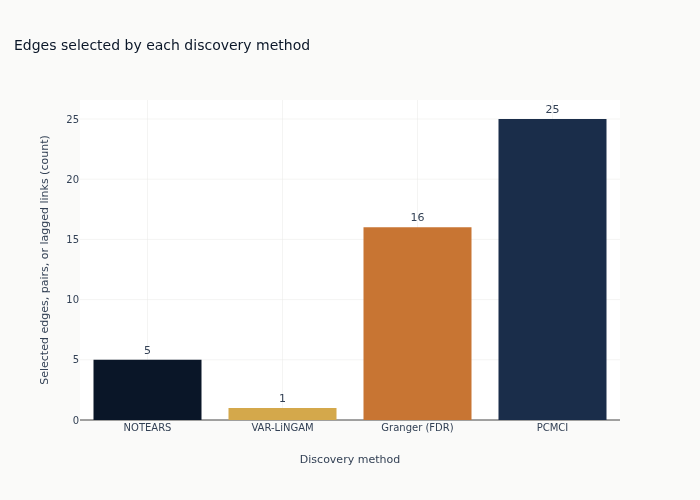

In [27]:
fig_counts = go.Figure(
    go.Bar(
        x=summary_df["Method"],
        y=summary_df["Edges_Found"],
        marker_color=[COLORS["blue"], COLORS["amber"], COLORS["copper"], COLORS["slate"]],
        text=summary_df["Edges_Found"],
        textposition="outside",
        hovertemplate="%{x}: %{y}<extra></extra>",
    )
)
fig_counts.update_layout(
    title=dict(
        text="Edges selected by each discovery method",
        x=0.02,
        xanchor="left",
    ),
    xaxis_title="Discovery method",
    yaxis_title="Selected edges, pairs, or lagged links (count)",
    showlegend=False,
)
fig_counts.update_yaxes(rangemode="tozero")
show_plotly_with_alt(
    fig_counts,
    "Bar chart with one bar per discovery method - NOTEARS, VAR-LiNGAM, Granger and PCMCI - "
    "showing how many edges, directed pairs or lagged links each selected, with the count "
    "printed above each bar. The four quantities are counts of different objects and are not "
    "interchangeable.",
)

## 12. Visualize Discovered Causal Graph

In [28]:
def _add_directed_edge(fig, x0, y0, x1, y1, mid_x, mid_y, color, width, hover):
    """Render one directed edge with a curved segment and arrow annotation."""
    dx, dy = x1 - x0, y1 - y0
    distance = np.hypot(dx, dy)
    node_padding = 0.14
    start_x = x0 + node_padding * dx / distance
    start_y = y0 + node_padding * dy / distance
    end_x = x1 - node_padding * dx / distance
    end_y = y1 - node_padding * dy / distance
    fig.add_trace(
        go.Scatter(
            x=[start_x, mid_x, end_x],
            y=[start_y, mid_y, end_y],
            mode="lines",
            line=dict(color=color, width=width),
            hoverinfo="text",
            hovertext=hover,
            showlegend=False,
        )
    )
    fig.add_annotation(
        x=end_x,
        y=end_y,
        ax=mid_x,
        ay=mid_y,
        xref="x",
        yref="y",
        axref="x",
        ayref="y",
        showarrow=True,
        arrowhead=2,
        arrowsize=1.0,
        arrowwidth=width,
        arrowcolor=color,
    )

Iterate through adjacency entries and draw only non-zero directed edges.

In [29]:
def _add_graph_edges(fig, W, labels, x_nodes, y_nodes, stability=None):
    """Add directed edges with optional stability coloring."""
    for i in range(len(labels)):
        for j in range(len(labels)):
            if abs(W[i, j]) <= 0:
                continue
            weight = W[i, j]
            edge_key = (labels[i], labels[j])
            has_stability = stability and edge_key in stability
            if has_stability:
                stability_value = stability[edge_key]
                color = COLORS["positive"] if stability_value >= 0.5 else COLORS["amber"]
            else:
                stability_value = None
                color = COLORS["positive"] if weight > 0 else COLORS["negative"]
            width = min(max(abs(weight) * 3, 1.5), 4)
            mid_x = (x_nodes[i] + x_nodes[j]) / 2 + 0.1 * (y_nodes[j] - y_nodes[i])
            mid_y = (y_nodes[i] + y_nodes[j]) / 2 - 0.1 * (x_nodes[j] - x_nodes[i])
            hover = f"{labels[i]} → {labels[j]}: {weight:.3f}"
            if stability_value is not None:
                hover += f" ({stability_value:.0%})"
            _add_directed_edge(
                fig,
                x_nodes[i],
                y_nodes[i],
                x_nodes[j],
                y_nodes[j],
                mid_x,
                mid_y,
                color,
                width,
                hover,
            )

Build a circular network view for the discovered weighted adjacency matrix.

In [30]:
def create_causal_graph_viz(
    W: np.ndarray,
    labels: list,
    title: str,
    stability: dict = None,
) -> go.Figure:
    """Create circular network visualization of a causal graph."""
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    x_nodes, y_nodes = np.cos(angles), np.sin(angles)

    fig = go.Figure()
    _add_graph_edges(fig, W, labels, x_nodes, y_nodes, stability)

    fig.add_trace(
        go.Scatter(
            x=x_nodes,
            y=y_nodes,
            mode="markers+text",
            marker=dict(size=40, color=COLORS["blue"]),
            text=labels,
            textposition="middle center",
            textfont=dict(size=10, color=COLORS["silver"]),
            hoverinfo="text",
            hovertext=labels,
            showlegend=False,
        )
    )
    # Edge colour is the only thing carrying stability, or sign, so it needs naming on the
    # chart: an arrow drawn in one of two colours says nothing to a reader without a key.
    key = (
        [("Recovered in most resamples", "positive"), ("Recovered in few", "amber")]
        if stability
        else [("Positive weight", "positive"), ("Negative weight", "negative")]
    )
    for name, color in key:
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="lines",
                line=dict(color=COLORS[color], width=3),
                name=name,
            )
        )
    fig.update_layout(
        title=dict(text=title, x=0.02, xanchor="left"),
        showlegend=True,
        legend=dict(orientation="h", yanchor="bottom", y=-0.08, xanchor="left", x=0),
        height=520,
        width=720,
        margin=dict(l=40, r=40, t=80, b=60),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    )
    return fig

The first network shows contemporaneous NOTEARS edges with bootstrap frequency in the
hover label. The second shows the lagged edges retained by structural VAR-LiNGAM.

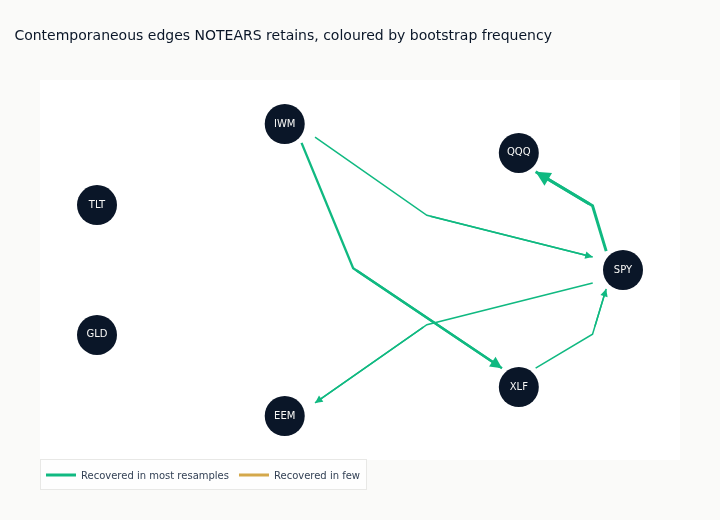

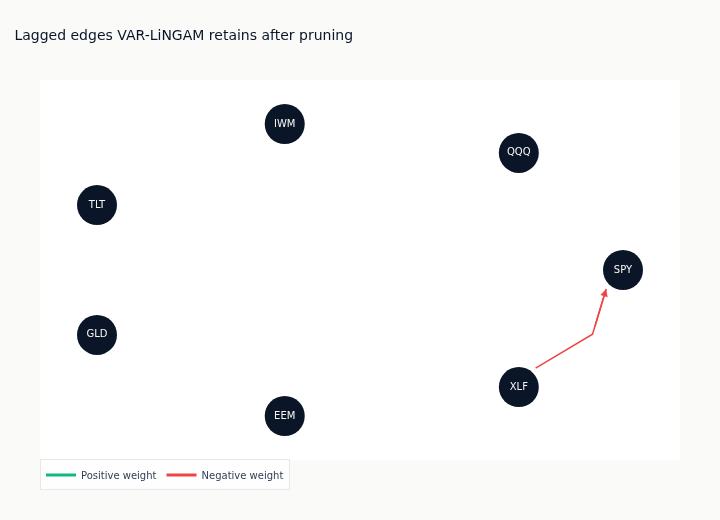

In [31]:
edge_stability_dict = {edge: edge_counts.get(edge, 0) / N_BOOTSTRAP for edge in full_sample_edges}

fig1 = create_causal_graph_viz(
    W_notears,
    ASSETS,
    "Contemporaneous edges NOTEARS retains, coloured by bootstrap frequency",
    stability=edge_stability_dict,
)
show_plotly_with_alt(
    fig1,
    "Network diagram with the assets placed around an ellipse, one labelled disc each, and "
    "an arrow for every contemporaneous edge the NOTEARS fit retains on the full sample. "
    "Arrow thickness follows the edge weight and arrow colour separates edges recovered in "
    "most block-bootstrap resamples from the rest, as the legend below the plot states. Each "
    "arrow's hover label carries its weight and its bootstrap frequency, and an asset the "
    "fit gives no retained edge sits on the ellipse unconnected.",
)

# Lagged effects from the causal-learn VAR-LiNGAM fit
n_var_lagged = int(np.sum(np.abs(B_lag) > 0))
fig2 = create_causal_graph_viz(
    B_lag.T,
    ASSETS,
    "Lagged edges VAR-LiNGAM retains after pruning",
)
show_plotly_with_alt(
    fig2,
    "Network diagram with the same assets in the same positions, and an arrow for every "
    "lagged edge the pruned VAR-LiNGAM fit retains. Arrow colour separates positive from "
    "negative coefficients, as the legend below the plot states, thickness follows the "
    "coefficient's size, and the hover label carries its value. An asset the pruned fit "
    "leaves with no lagged edge sits on the ellipse unconnected.",
)

## 13. Interpretation: Hypotheses for Further Investigation

**CRITICAL**: Discovered edges are **HYPOTHESES**, not proven causation.

### Validation Steps Before Any Trading Use

1. **Out-of-sample testing**: Split data temporally, discover on training, validate on test
2. **Bootstrap stability**: consider only edges recovered in a majority of the bootstrap
   resamples
3. **Multiple method agreement**: Edges confirmed by NOTEARS, VAR-LiNGAM, AND Granger
4. **Economic rationale**: Does the relationship make economic sense?
5. **DML/BSTS validation**: Use proper causal inference to estimate effect magnitude

### Why Edges May Be Spurious

- **Omitted confounders**: Common macro factors drive both assets
- **Non-stationarity**: Regime changes invalidate constant edge weights
- **Sample dependence**: Results sensitive to time period
- **Hyperparameter sensitivity**: Different λ gives different graphs

In [32]:
print("\n=== INTERPRETATION: HYPOTHESES FOR INVESTIGATION ===\n")

# Identify most robust relationships
print("Most Robust Findings:")

# Report only edges that are present in the full-sample graph and recur in at least
# half of bootstrap samples.
robust_edges = []
for e in bootstrap_edges:
    if e["Consensus"] and e["In_Full_Sample"]:
        source, target = e["Source"], e["Target"]
        i, j = ASSETS.index(source), ASSETS.index(target)
        weight = W_notears[i, j]
        robust_edges.append(
            {
                "Edge": f"{source} → {target}",
                "Weight": weight,
                "Bootstrap_Freq": e["Frequency"],
            }
        )

if robust_edges:
    robust_df = pd.DataFrame(robust_edges).sort_values("Bootstrap_Freq", ascending=False)
    display(robust_df)
else:
    print("No edges meet stability threshold (≥50% bootstrap frequency).")
    print("This suggests high sensitivity to sample - proceed with caution.")


=== INTERPRETATION: HYPOTHESES FOR INVESTIGATION ===

Most Robust Findings:


,Edge,Weight,Bootstrap_Freq
0,SPY → QQQ,0.982135,1.00
1,IWM → SPY,0.489528,0.98
2,IWM → XLF,0.779560,0.87
3,XLF → SPY,0.400098,0.71
4,SPY → EEM,0.348043,0.64


## 14. Key Takeaways

- **Method choice changes the object being selected.** NOTEARS estimates contemporaneous
  structure, while the time-series methods select lagged links or predictive pairs.
- **Multiplicity control materially thins the graphs.** FDR is applied across all PCMCI
  source-target-lag hypotheses and across the fixed-order Granger pair tests.
- **Bootstrap frequency is not enough by itself.** A robust NOTEARS claim now requires an
  edge to appear in the full-sample graph and in at least half of refitted bootstrap graphs.
- **Every discovered edge remains a hypothesis.** Latent confounding, nonstationarity,
  threshold sensitivity, and the absence of any out-of-sample test prevent a trading
  interpretation.

Next, use `09_adia_causal_benchmark` to examine what supervised discovery can learn when
many labeled synthetic graphs are available. See Chapter 15, Section 15.6.